In [1]:
import sys
from pathlib import Path
import pandas as pd

# 1. Compute project root (one level up from notebooks/)
project_root = Path.cwd().parent

# 2. Make src/ importable
sys.path.insert(0, str(project_root / "src"))

# 3. Define where your data lives
data_dir = project_root / "data"

# 4. Read your CSV
df = pd.read_csv(data_dir / "banking_complaints.csv")
df.head()


,Complaint ID,Date Received,Banking Product,Issue ID,Complaint Description,State,ZIP,Bank Response
0,CID76118977,1/1/2023,Checking or savings account,I_3510635,on XX/XX/XX22 I opened a safe balance account ...,California,92311,Closed with monetary relief
1,CID98703933,1/1/2023,"Credit reporting, credit repair services, or o...",I_3798538,There is an item from Bank of ABC on my credit...,California,91344,Closed with explanation
2,CID52036665,1/1/2023,Checking or savings account,I_3648593,On XX/XX/XX22 I found out that my account was ...,New York,10466,Closed with monetary relief
3,CID62581335,1/1/2023,Credit card or prepaid card,I_6999080,I've had a credit card for years with Bank of ...,California,92127,Closed with monetary relief
4,CID65731164,1/1/2023,Checking or savings account,I_3648593,This issue has to do with the way that Bank of...,New Jersey,7946,Closed with explanation


In [2]:
# Cell 2: Download NLTK data (one-time)
import nltk

# Stopwords for filtering, WordNet + omw for lemmatization
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sheilamcgovern/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sheilamcgovern/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/sheilamcgovern/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
from data_utils import load_data, check_types
from preprocess   import preprocessing

df = load_data(project_root/"data"/"banking_complaints.csv")

# check types & missing
check_types(df)

# apply preprocessing to the complaint text
df['cleaned_description'] = df['Complaint Description'].fillna("").apply(preprocessing)
df[['Complaint Description','cleaned_description']].head()


Complaint ID             object
Date Received            object
Banking Product          object
Issue ID                 object
Complaint Description    object
State                    object
ZIP                      object
Bank Response            object
dtype: object

Missing values per column:
Complaint ID              0
Date Received             0
Banking Product           0
Issue ID                  0
Complaint Description     0
State                    27
ZIP                      30
Bank Response             0
dtype: int64


,Complaint Description,cleaned_description
0,on XX/XX/XX22 I opened a safe balance account ...,xx xx xx opened safe balance account online ...
1,There is an item from Bank of ABC on my credit...,item bank abc credit report belong must remove...
2,On XX/XX/XX22 I found out that my account was ...,xx xx xx found account frozen apparent reaso...
3,I've had a credit card for years with Bank of ...,'ve credit card year bank abc xx xx xxxx paid ...
4,This issue has to do with the way that Bank of...,issue way bank abc account linking bill pay pa...


In [4]:
# 4: Convert Date Received to datetime
df['Date Received'] = pd.to_datetime(df['Date Received'], errors='coerce')

# 5: Check the conversion
print(df['Date Received'].dtype)
print("Date range:", df['Date Received'].min(), "→", df['Date Received'].max())


datetime64[ns]
Date range: 2023-01-01 00:00:00 → 2023-10-21 00:00:00


In [5]:
from pathlib import Path
import pandas as pd

#–– set project_root to one level up from wherever your notebook lives
project_root = Path.cwd().parent  

#–– load & peek
df = pd.read_csv(project_root/"data"/"banking_complaints.csv")
df.head()

#–– check types and nulls
df.info()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7011 entries, 0 to 7010
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Complaint ID           7011 non-null   object
 1   Date Received          7011 non-null   object
 2   Banking Product        7011 non-null   object
 3   Issue ID               7011 non-null   object
 4   Complaint Description  7011 non-null   object
 5   State                  6984 non-null   object
 6   ZIP                    6981 non-null   object
 7   Bank Response          7011 non-null   object
dtypes: object(8)
memory usage: 438.3+ KB


Complaint ID              0
Date Received             0
Banking Product           0
Issue ID                  0
Complaint Description     0
State                    27
ZIP                      30
Bank Response             0
dtype: int64

Date range: 2023-01-01 00:00:00 to 2023-10-21 00:00:00


/var/folders/_w/1v5jxkz56qxcjphx0msmcxr00000gn/T/ipykernel_83970/3818562866.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('Date Received').resample('M').size().plot()


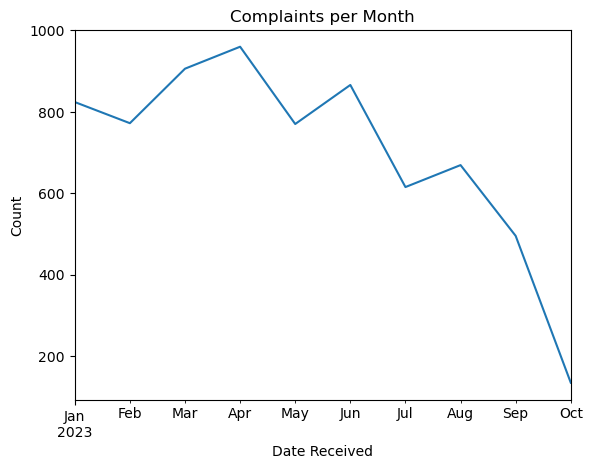

In [6]:
# ensure datetime
df['Date Received'] = pd.to_datetime(df['Date Received'], errors='coerce')

# overall min/max
print("Date range:", df['Date Received'].min(), "to", df['Date Received'].max())

# maybe plot counts by month
import matplotlib.pyplot as plt
df.set_index('Date Received').resample('M').size().plot()
plt.title("Complaints per Month")
plt.ylabel("Count")
plt.show()


In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocessing(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)                      # remove numbers
    text = re.sub(r'[^\w\s]', '', text)                  # remove punctuation
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]  # drop stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]    # lemmatize
    return ' '.join(tokens)

# apply
df['clean_text'] = df['Complaint Description'].fillna('').apply(preprocessing)
df[['Complaint Description','clean_text']].head()


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sheilamcgovern/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/sheilamcgovern/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Complaint Description,clean_text
0,on XX/XX/XX22 I opened a safe balance account ...,xxxxxx opened safe balance account online usin...
1,There is an item from Bank of ABC on my credit...,item bank abc credit report belong must remove...
2,On XX/XX/XX22 I found out that my account was ...,xxxxxx found account frozen apparent reason we...
3,I've had a credit card for years with Bank of ...,ive credit card year bank abc xxxxxxxx paid ba...
4,This issue has to do with the way that Bank of...,issue way bank abc account linking bill pay pa...


In [9]:
# already created df['clean_text']
X = df['clean_text']

# use the real column name  
y = df['Banking Product']

# drop missing targets
mask = y.notna()
X = X[mask]
y = y[mask]

# vectorize & split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection   import train_test_split

vectorizer = TfidfVectorizer(max_features=10_000)
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)

# train & evaluate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics        import classification_report

clf = LogisticRegression(max_iter=1_000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))



                                                                              precision    recall  f1-score   support

                                                     Bank account or service       1.00      0.17      0.29        48
                                                 Checking or savings account       0.65      0.83      0.73       350
                                                               Consumer Loan       0.83      0.28      0.42        18
                                                                 Credit card       0.82      0.47      0.60        66
                                                 Credit card or prepaid card       0.67      0.72      0.70       237
                                                            Credit reporting       0.69      0.77      0.73        93
Credit reporting, credit repair services, or other personal consumer reports       0.77      0.58      0.66       125
                                                       

/Users/sheilamcgovern/anaconda3/envs/nlp-dev/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sheilamcgovern/anaconda3/envs/nlp-dev/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sheilamcgovern/anaconda3/envs/nlp-dev/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [10]:
!pip install transformers torch

from transformers import pipeline

# load a pre-trained model
pipe = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    return_all_scores=False
)

# example
sample = df['Complaint Description'].iloc[:5].tolist()
pipe(sample)


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use mps:0
/Users/sheilamcgovern/anaconda3/envs/nlp-dev/lib/python3.11/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


[{'label': 'NEGATIVE', 'score': 0.9994292855262756},
 {'label': 'NEGATIVE', 'score': 0.999339759349823},
 {'label': 'NEGATIVE', 'score': 0.999525785446167},
 {'label': 'NEGATIVE', 'score': 0.9985606074333191},
 {'label': 'NEGATIVE', 'score': 0.9992176294326782}]

In [11]:
!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

# get compound score
df['vader_compound'] = df['Complaint Description'].fillna('').apply(
    lambda txt: analyzer.polarity_scores(txt)['compound']
)

# bucket into negative/neutral/positive
df['vader_label'] = pd.cut(
    df['vader_compound'],
    bins=[-1, -0.05, 0.05, 1],
    labels=['negative','neutral','positive']
)

df['vader_label'].value_counts()


vader_label
negative    3820
positive    2873
neutral      318
Name: count, dtype: int64